# Insper - Modelagem e Simulação do Mundo Físico

## Exercício de programação 2

---

### Contexto
   
Neste exercício, vamos entender melhor os conceitos de derivada e de equações diferenciais. Primeiramente, você já deve estar se acostumando com o conceito de derivada, que chamamos de "taxa de variação instantânea". Você já deve ter entendido que a taxa de variação temporal (média) de uma função no intervalo de tempo $t_1$ e $t_2$ é dada por:
   
$$\frac{\Delta f}{\Delta t}=\frac{f(t_2)-f(t_1)}{t_2-t_1}$$
   
Pois bem, já está ficando bem chato repetir que você ainda vai aprender em MatVar que quando $t_2$ é muito próximo de $t_1$ a taxa de variação será chamada de derivada (já sacou, né?). Mais uma vez:
   
$$\frac{df}{dt}=\lim_{t_2 \to t_1}\frac{f(t_2)-f(t_1)}{t_2-t_1}$$
   
Você deve estar muito ansioso(a) para aprender como calcular algebricamente a derivada de vários tipos de funcões, mas, por enquanto, vamos trabalhar o conceito da taxa de variação em um ponto, e construir uma série temporal de taxas para vários pontos. Ou seja, se começarmos a calcular as taxas de variação de uma determinada função quanto $t=0$ e formos incrementando esse $t$ a passos bem pequenos, poderemos calcular a taxa de variação a cada intervalo $\Delta t$, construindo uma lista de taxas de variação. A essa lista de taxas de variação, daremos o nome de "função derivada".


---
### Item 1 - Implementando numericamente a função derivada

Vamos começar implementando uma função bem simples e muito conhecida por você: $f(t)=t^2$



#### a)

Na célula abaixo, escreva uma função em Python para a implementação dessa função matemática. Perceba que estamos pedido apenas para **implementar** a função, não para executá-la!

In [8]:
def f(t):
    f_t=t**2
    return f_t

#### b)

Para se certificar de que sua função funciona, plote um gráfico de $f(t)$ para $t$ variando de 0 a 10 com intervalos de tempo de 0,01s. Use a função `arange()` do módulo `numpy` para criar uma lista de tempo. Note que, na célula abaixo, você não precisa implementar a função novamente (ela foi implementada na célula anterior), você vai apenas **executá-la** e plotar o gráfico em seguida.

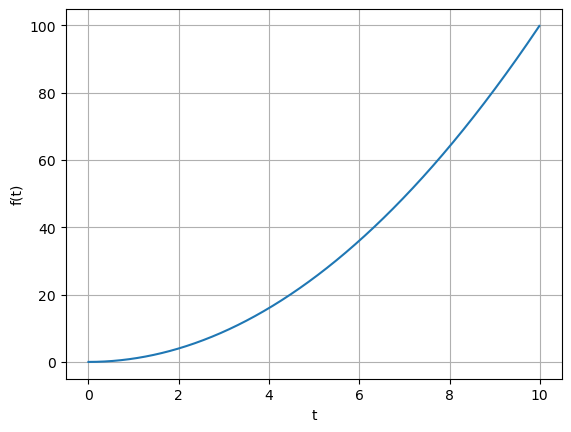

In [45]:
import numpy as np
import matplotlib.pyplot as plt

t_lista=np.arange(0,10,0.01)
f_lista=f(t_lista)

plt.plot(t_lista,f_lista)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.grid()





#### c)

Agora que sua função já está funcionando, vamos implementar o cálculo das taxas de variação de $f(t)$ para um determinado intervalo de tempo. Para isso, vamos criar uma função chamada `f_taxa(t, dt)`, que deve retornar a taxa de variação no instante $t$ considerando um determinado $\Delta t$. Para isso, use a função `f(t)` que você já implementou!

In [46]:
def f_taxa(t,dt):
    dfdt=(f(t+dt)-f(t))/dt
    return dfdt

#### d)

Vamos construir o gráfico da série temporal de $f(t)$ e da taxa de variação $\frac{\Delta f}{\Delta t}(t)$. Para isso, vamos criar duas listas vazias, uma denominada `f_lista`, com os valores de $f(t)$, e outra chamada `f_taxa_lista`, com os valores de $\frac{\Delta f}{\Delta t}(t)$. Use inicialmente o mesmo $\Delta t$ de 0,01s com $t$ entre 0 e 10.

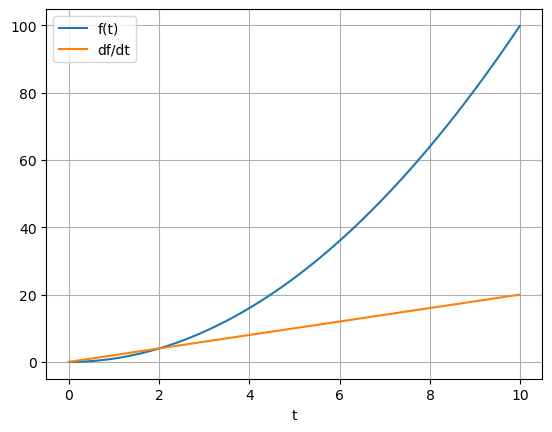

In [47]:
f_lista=f(t_lista)
f_taxa_lista=f_taxa(t_lista,0.01)

plt.plot(t_lista, f_lista, label="f(t)")
plt.plot(t_lista, f_taxa_lista, label="df/dt")
plt.xlabel("t")
plt.grid()
plt.legend()




O gráfico da taxa de variação $\frac{\Delta f}{\Delta t}(t)$ é de uma função de que grau? Você consegue determinar a lei da função cujo gráfico é  parecido com esse? Consegue calcular seu coeficiente angular? Uma sugestão é plotar o gráfico acima com a grade ativa. Para isso, use `plt.grid(True)`.

#### e)

Agora crie uma outra função, denominada $g(t)$. Em vez de $f(t)=t^2$, faça agora $g(t)=e^t$ ($e$ é o número de Euler). Plote os gráficos $g(t)$ por $t$ e $\frac{\Delta g}{\Delta t}(t)$ por $t$ em uma mesma figura e observe a relação entre eles.

Dica: o Python possui diversas funções matemáticas, tais como `sin(x)`, `cos(x)`, `exp(x)`, etc. Para utilizá-las, basta importar a biblioteca `from math import *`.

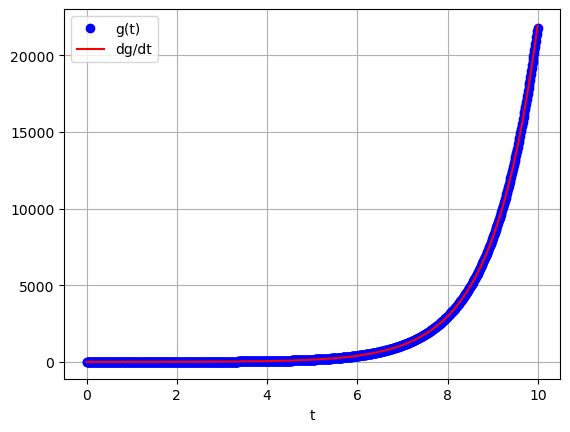

In [28]:
import math as m

def g(t):
    g_t=m.e**t
    return g_t

g_lista=g(t_lista)

def g_taxa(t, dt):
    dgdt=(g(t+dt)-g(t))/dt
    return dgdt

g_lista_taxa=g_taxa(t_lista, 0.01)

plt.plot(t_lista, g_lista,"bo", label="g(t)")
plt.plot(t_lista, g_lista_taxa,"r", label="dg/dt")
plt.grid()
plt.xlabel("t")
plt.legend()






#### f)

Por fim, com o mesmo $\Delta t$, crie mais uma função: $h(t)=cos(t)$. Novamente plote os gráficos $h(t)$ por $t$ e $\frac{\Delta h}{\Delta t}(t)$ por $t$ em uma mesma figura e observe a relação entre eles.

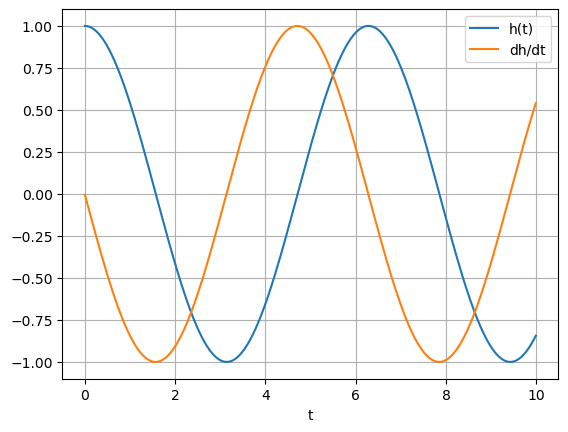

In [48]:
def h(t):
    h_t=np.cos(t)
    return h_t

h_lista=h(t_lista)

def h_taxa(t, dt):
    dhdt=(h(t+dt)-h(t))/dt
    return dhdt
h_lista_taxa=h_taxa(t_lista, 0.01)

plt.plot(t_lista, h_lista, label="h(t)")
plt.plot(t_lista, h_lista_taxa, label="dh/dt")
plt.grid()
plt.xlabel("t")
plt.legend()



Pesquise na internet qual o resultado algébrico das derivadas das funções $f(x)=x^2$, $g(x)=e^x$ e $h(x)=cos(x)$. Faz sentido em face ao que você implementou? Quando aprender o método algébrico para determinar as funções derivadas em MatVar, não se esqueça de que já constatou numericamente esses três casos em ModSim! Lembre-se: você pode calcular todas as derivadas numericamente por meio da definição de taxa de variação!

---
### Item 2 -  Resolvendo uma equação diferencial pelo método de Euler

Vamos imaginar que queiramos saber qual a solução de uma equação diferencial do tipo $\frac{dy}{dt}=f(y, t)$.

Por exemplo, uma equação que seja dada pela expressão abaixo:

$$\frac{dy}{dt}=a\cdot y\cdot(1+2\cdot \sin(\omega \cdot t))$$

Essa equação representa a evolução diária da população de bactérias em um determinado meio, que depende da quantidade de bactéricas existentes e de uma função senoidal que representa a sazonalidade do processo.

Pois bem, vamos encontrar qual função $y(t)$ é solução da equação diferencial acima. Para isso, vamos usar, mais uma vez, o método de Euler.

#### a)

Primeiramente, implemente abaixo uma função chamada `modelo(y, t, a, w)`, que recebe os quatro parâmetros indicados, nessa ordem. Essa função deve retornar o lado direito da equação $\frac{dy}{dt}$.

In [49]:
def modelo(y,t,a,w):
    dydt=a*y*(1+2*m.sin(w*t))
    return dydt


#### b)

Agora que sua função está implementada, vamos calcular a série temporal da função $y(t)$ que satisfaz a equação diferencial que estamos tentando resolver. Os valores da função $y(t)$ estarão numa lista, com cada elemento correspondendo a cada instante de tempo considerado. Abaixo, implemente o código do método de Euler executando a função `modelo(y, t, a, w)` e usando os seguintes parâmetros:

- $y(0) = 5$ (população inicial de bactérias)
- $a = 0,007$ (parâmetro do modelo)
- $\omega=0,05$ (parâmetro do modelo)
- $\Delta t=0,001$ dias (nosso $\Delta t$ é um milésimo de um 1 dia)

Para sua implementação, use 400 dias de simulação.

Qual a população de bactérias após 1 ano (365 dias)?


67.57580998901688 bactérias


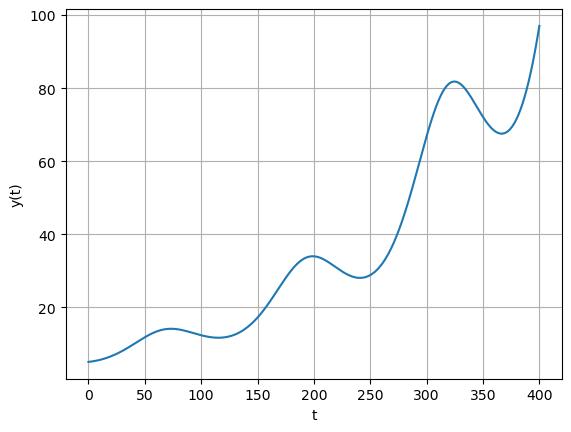

In [58]:
t_lista=np.arange(0,400, 0.001)
y_t=[5]*(len(t_lista))
i=0
while i<len(t_lista)-1:
    y_t[i+1]=y_t[i]+modelo(y_t[i], t_lista[i], 0.007, 0.05)*0.001
    i+=1

print(f"{y_t[365*1000]} bactérias")
plt.plot(t_lista, y_t)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid()
    


---
### Item 3 - Resolvendo a mesma equação diferencial utilizando a função `odeint`

Usando a mesma função `modelo(y, t, a, w)` que você já implementou, escreva uma ou duas linhas de código para executar a função `odeint` de modo a obter a solução para a mesma equação diferencial do item anterior. Plote um gráfico da solução dada pelo `odeint` e compare com a que você obteve pelo método de Euler. São muito parecidas?

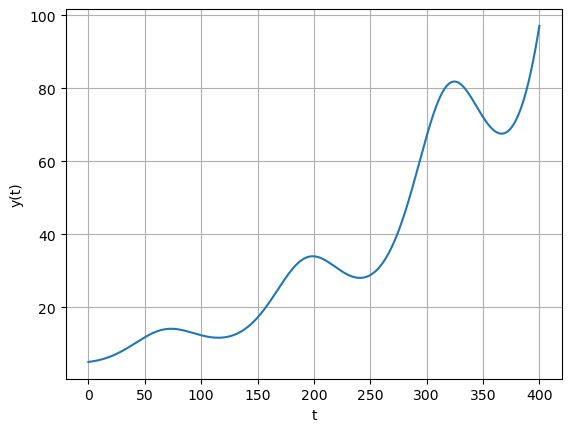

In [43]:
from scipy.integrate import odeint
y_t=odeint(modelo, 5, t_lista, args=(0.007,0.05))

plt.plot(t_lista, y_t)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid()

In [ ]:
São muito parecidos!